# Week 12 — Tuesday (Jun 23, Remote): DeepLab

## Learning Objectives
- Understand atrous (dilated) convolution and why it preserves resolution
- Build Atrous Spatial Pyramid Pooling (ASPP) from scratch
- Trace the DeepLabv1 → v2 → v3 → v3+ architectural evolution
- Implement a DeepLabv3+ style encoder-decoder in PyTorch
- Compare DeepLab vs U-Net on a synthetic segmentation task

## Key Concepts
1. **Atrous conv** — insert zeros (holes) inside the kernel to expand receptive field without extra params or stride
2. **Dilation rate r** — spacing between kernel values; effective receptive field = `k + (k-1)(r-1)`
3. **ASPP** — four parallel atrous convs at different rates capture multi-scale context in one module
4. **DeepLabv3+** — ASPP encoder + lightweight decoder with low-level skip feature from backbone
5. **Output stride** — ratio of input to feature map size; DeepLab uses OS=16 or OS=8 (vs 32 in plain ResNet)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

plt.rcParams['figure.figsize'] = (14, 6)
np.random.seed(42)
torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {DEVICE}')
print('Setup complete')

PyTorch 2.12.0+cpu | Device: cpu
Setup complete


## Section 1: Atrous (Dilated) Convolution

### The Problem
Standard segmentation: encoder downsamples to stride 32 → loses spatial resolution.  
FCN/U-Net solution: upsample back with transposed conv or bilinear.  
DeepLab's solution: **never downsample that much in the first place**.

### Atrous Convolution
A 3×3 conv with dilation rate `r=2` has the same **parameter count** as a regular 3×3 conv but behaves like a 5×5 conv in terms of receptive field — it skips one pixel between each kernel element.

```
Standard 3×3 (r=1)      Atrous 3×3 (r=2)        Atrous 3×3 (r=4)
■ ■ ■                    ■ · ■ · ■               ■ · · · ■ · · · ■
■ ■ ■                    · · · · ·               · · · · · · · · ·
■ ■ ■                    ■ · ■ · ■               · · · · · · · · ·
RF = 3×3                 RF = 5×5               RF = 9×9
params = 9               params = 9              params = 9
```

**Key insight:** Atrous conv achieves large receptive fields without reducing spatial resolution or adding parameters.

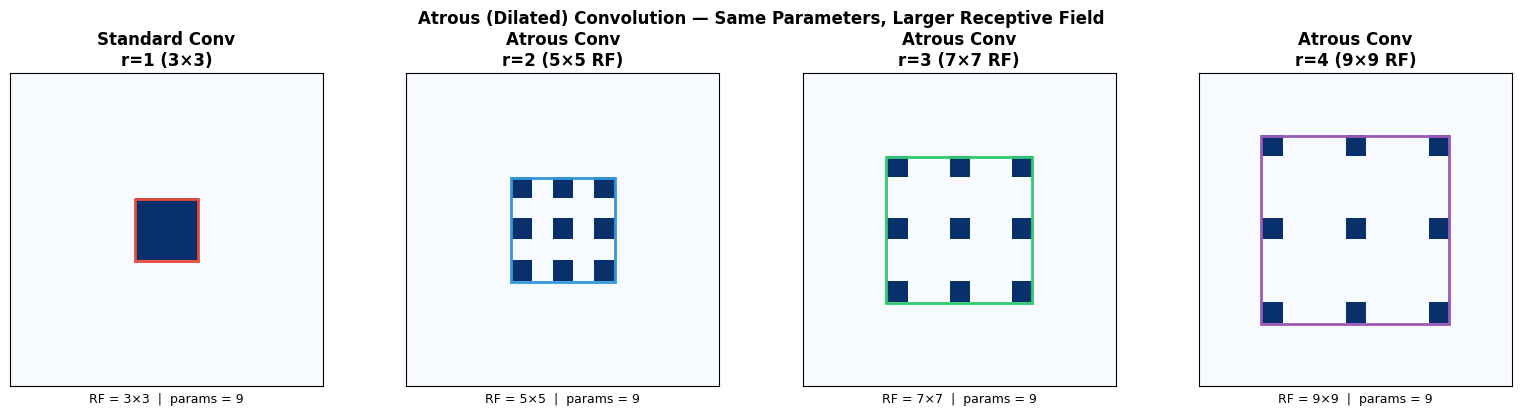

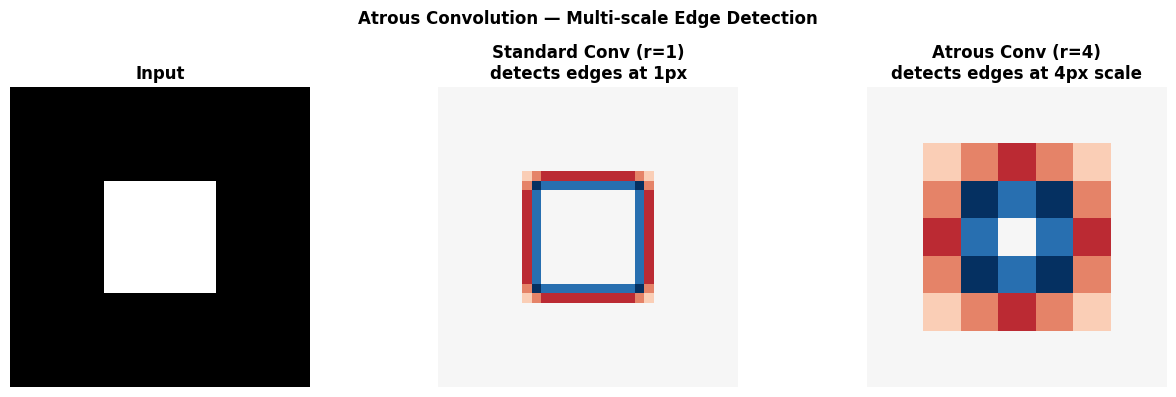

Saved atrous_receptive_fields.png  atrous_feature_maps.png


In [2]:
# ── Visualise atrous convolution receptive fields ──────────────────────────────
def draw_receptive_field(ax, rate, color, title):
    grid_size = 15
    grid = np.zeros((grid_size, grid_size))
    # 3×3 kernel positions with dilation
    center = grid_size // 2
    offsets = [-rate, 0, rate]
    positions = [(center + dy, center + dx) for dy in offsets for dx in offsets]
    for (r, c) in positions:
        if 0 <= r < grid_size and 0 <= c < grid_size:
            grid[r, c] = 1.0
    ax.imshow(grid, cmap='Blues', vmin=0, vmax=1, interpolation='none')
    ax.set_title(title, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    # Shade receptive field region
    rmin = min(r for r, c in positions); rmax = max(r for r, c in positions)
    cmin = min(c for r, c in positions); cmax = max(c for r, c in positions)
    rect = plt.Rectangle((cmin-0.5, rmin-0.5), cmax-cmin+1, rmax-rmin+1,
                          linewidth=2, edgecolor=color, facecolor='none')
    ax.add_patch(rect)
    rf = (rmax - rmin + 1)
    ax.set_xlabel(f'RF = {rf}×{rf}  |  params = 9', fontsize=9)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
configs = [(1, '#e74c3c', 'Standard Conv\nr=1 (3×3)'),
           (2, '#3498db', 'Atrous Conv\nr=2 (5×5 RF)'),
           (3, '#2ecc71', 'Atrous Conv\nr=3 (7×7 RF)'),
           (4, '#9b59b6', 'Atrous Conv\nr=4 (9×9 RF)')]
for ax, (rate, col, title) in zip(axes, configs):
    draw_receptive_field(ax, rate, col, title)

plt.suptitle('Atrous (Dilated) Convolution — Same Parameters, Larger Receptive Field',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('atrous_receptive_fields.png', dpi=100, bbox_inches='tight')
plt.show()

# ── Compare feature maps: standard vs atrous ───────────────────────────────────
signal = np.zeros((1, 1, 32, 32), dtype=np.float32)
signal[0, 0, 10:22, 10:22] = 1.0   # white square
t = torch.from_numpy(signal)

std_conv    = nn.Conv2d(1, 1, 3, padding=1,        dilation=1, bias=False)
atrous_conv = nn.Conv2d(1, 1, 3, padding=4,        dilation=4, bias=False)
edge_kernel = torch.tensor([[-1,-1,-1],[-1,8,-1],[-1,-1,-1]], dtype=torch.float32).view(1,1,3,3)
std_conv.weight.data    = edge_kernel
atrous_conv.weight.data = edge_kernel

with torch.no_grad():
    out_std    = std_conv(t).squeeze().numpy()
    out_atrous = atrous_conv(t).squeeze().numpy()

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(signal[0, 0], cmap='gray'); axes[0].set_title('Input', fontweight='bold')
axes[1].imshow(out_std,    cmap='RdBu', vmin=-4, vmax=4); axes[1].set_title('Standard Conv (r=1)\ndetects edges at 1px', fontweight='bold')
axes[2].imshow(out_atrous, cmap='RdBu', vmin=-4, vmax=4); axes[2].set_title('Atrous Conv (r=4)\ndetects edges at 4px scale', fontweight='bold')
for ax in axes: ax.axis('off')
plt.suptitle('Atrous Convolution — Multi-scale Edge Detection', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('atrous_feature_maps.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved atrous_receptive_fields.png  atrous_feature_maps.png')

## Section 2: DeepLab Architecture Evolution

| Version | Year | Key Contribution |
|---------|------|------------------|
| **DeepLabv1** | 2015 | Atrous conv + CRF post-processing |
| **DeepLabv2** | 2017 | ASPP (Atrous Spatial Pyramid Pooling) |
| **DeepLabv3** | 2017 | Improved ASPP + global average pooling branch |
| **DeepLabv3+** | 2018 | Encoder-decoder with ASPP + low-level features |

### Atrous Spatial Pyramid Pooling (ASPP)
Inspired by Spatial Pyramid Pooling (SPP): run multiple atrous convs in **parallel** at different rates to capture features at multiple scales simultaneously.

```
Input feature map  (e.g. from ResNet layer3, stride 16)
        │
   ┌────┼────────────────────┐
   │    │                    │
 1×1   3×3 r=6  3×3 r=12  3×3 r=18   Global AvgPool
conv   atrous   atrous     atrous      → 1×1 conv → upsample
   │    │                    │              │
   └────┴────────────────────┴──────────────┘
                    concat → 1×1 proj
```

### DeepLabv3+ Decoder
```
Input → Backbone (ResNet) → Low-level feat (layer1, stride4) ──────────────┐
                         → ASPP (on layer3, stride16)                       │
                         → 4× upsample → 1×1 proj                          │
                         → concat low-level ────────────────────────────────┘
                         → 3×3 conv → 3×3 conv → 4× upsample → output
```

ASPP — input: (2, 64, 16, 16)  output: (2, 64, 16, 16)
ASPP params: 139,904


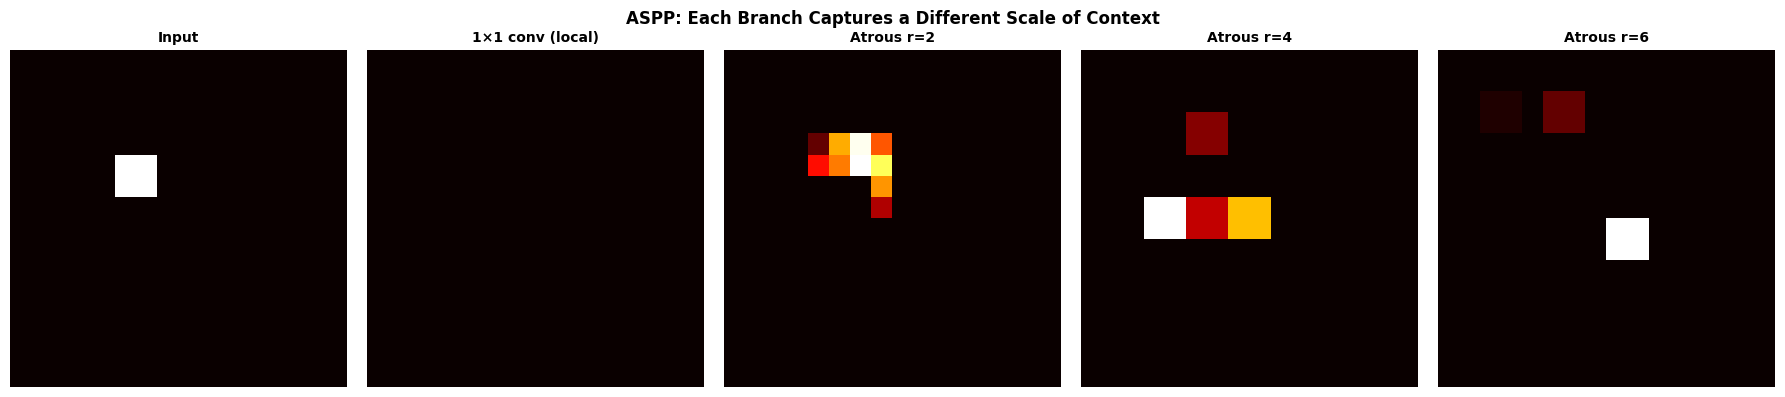

Saved aspp_branches.png


In [3]:
# ── ASPP module from scratch ──────────────────────────────────────────────────

class ConvBnReLU(nn.Module):
    def __init__(self, in_c, out_c, k=3, stride=1, padding=1, dilation=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, k, stride=stride,
                      padding=dilation if k > 1 else 0,
                      dilation=dilation, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.block(x)


class ASPP(nn.Module):
    """
    Atrous Spatial Pyramid Pooling.
    Runs 5 parallel branches at different scales and concatenates.
    """
    def __init__(self, in_channels=256, out_channels=256, rates=(6, 12, 18)):
        super().__init__()
        # Branch 1: 1×1 conv
        self.b1 = ConvBnReLU(in_channels, out_channels, k=1, padding=0)
        # Branches 2-4: atrous 3×3 at different rates
        self.b2 = ConvBnReLU(in_channels, out_channels, dilation=rates[0])
        self.b3 = ConvBnReLU(in_channels, out_channels, dilation=rates[1])
        self.b4 = ConvBnReLU(in_channels, out_channels, dilation=rates[2])
        # Branch 5: global average pooling — NO BatchNorm (spatial size = 1×1)
        self.gap = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.ReLU(inplace=True)
        )
        # Projection: concat(5 branches) → out_channels
        self.proj = ConvBnReLU(out_channels * 5, out_channels, k=1, padding=0)
        self.drop = nn.Dropout(0.1)

    def forward(self, x):
        h, w = x.shape[2:]
        b5 = F.interpolate(self.gap(x), size=(h, w), mode='bilinear', align_corners=False)
        out = torch.cat([self.b1(x), self.b2(x), self.b3(x), self.b4(x), b5], dim=1)
        return self.drop(self.proj(out))


# Test ASPP
aspp = ASPP(in_channels=64, out_channels=64)
dummy = torch.zeros(2, 64, 16, 16)
out = aspp(dummy)
params = sum(p.numel() for p in aspp.parameters())
print(f'ASPP — input: {tuple(dummy.shape)}  output: {tuple(out.shape)}')
print(f'ASPP params: {params:,}')

# ── Visualise ASPP branch outputs (eval mode to avoid BN issues) ───────────────
aspp_vis = ASPP(in_channels=1, out_channels=1, rates=(2, 4, 6))
aspp_vis.eval()

test_img = np.zeros((1, 1, 32, 32), dtype=np.float32)
test_img[0, 0, 10:14, 10:14] = 1.0   # small square
t_img = torch.from_numpy(test_img)

branch_outs = []
with torch.no_grad():
    branch_outs.append(aspp_vis.b1(t_img).squeeze().numpy())
    branch_outs.append(aspp_vis.b2(t_img).squeeze().numpy())
    branch_outs.append(aspp_vis.b3(t_img).squeeze().numpy())
    branch_outs.append(aspp_vis.b4(t_img).squeeze().numpy())

titles = ['Input', '1×1 conv (local)', 'Atrous r=2', 'Atrous r=4', 'Atrous r=6']
data   = [test_img[0,0]] + branch_outs
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, title, d in zip(axes, titles, data):
    ax.imshow(d, cmap='hot', interpolation='none')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.axis('off')
plt.suptitle('ASPP: Each Branch Captures a Different Scale of Context', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('aspp_branches.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved aspp_branches.png')

## Section 3: DeepLabv3+ from Scratch

We build a lightweight DeepLabv3+ using a simple CNN backbone (not ResNet-101) so it trains on CPU.

In [4]:
class SimpleBackbone(nn.Module):
    """
    Lightweight backbone with two feature exits:
      low_feat  : stride 4  (used for decoder skip)
      high_feat : stride 8  (fed into ASPP)
    """
    def __init__(self, in_channels=3):
        super().__init__()
        # Stage 1 — stride 2
        self.s1 = nn.Sequential(
            ConvBnReLU(in_channels, 32, stride=1),
            ConvBnReLU(32, 32),
            nn.MaxPool2d(2))           # /2
        # Stage 2 — stride 4  → low-level feature exit
        self.s2 = nn.Sequential(
            ConvBnReLU(32, 64),
            ConvBnReLU(64, 64),
            nn.MaxPool2d(2))           # /4
        # Stage 3 — stride 8  → ASPP feature exit (atrous instead of stride)
        self.s3 = nn.Sequential(
            ConvBnReLU(64, 128, dilation=1),
            ConvBnReLU(128, 128, dilation=2))  # stay at /4 but dilated

    def forward(self, x):
        x      = self.s1(x)
        low    = self.s2(x)     # stride /4
        high   = self.s3(low)   # stride /4, larger RF
        return low, high


class DeepLabV3Plus(nn.Module):
    """
    Lightweight DeepLabv3+ style model.
    Input : (B, 3, H, W)  — H,W divisible by 4
    Output: (B, num_classes, H, W)
    """
    def __init__(self, num_classes=4):
        super().__init__()
        self.backbone = SimpleBackbone()
        self.aspp     = ASPP(in_channels=128, out_channels=64, rates=(2, 4, 6))
        # Low-level feature projection (reduce channels)
        self.low_proj = ConvBnReLU(64, 32, k=1, padding=0)
        # Decoder: concat(64 + 32) → refine → classify
        self.decoder  = nn.Sequential(
            ConvBnReLU(64 + 32, 64),
            ConvBnReLU(64, 64),
            nn.Conv2d(64, num_classes, 1)
        )

    def forward(self, x):
        H, W        = x.shape[2:]
        low, high   = self.backbone(x)
        # ASPP on high-level features
        aspp_out    = self.aspp(high)                          # /4 spatial
        aspp_up     = F.interpolate(aspp_out, size=low.shape[2:],
                                    mode='bilinear', align_corners=False)
        # Decoder: concat ASPP + low-level
        low_p       = self.low_proj(low)
        dec         = self.decoder(torch.cat([aspp_up, low_p], dim=1))
        # Upsample to original resolution
        return F.interpolate(dec, size=(H, W), mode='bilinear', align_corners=False)


# ── Inspect ───────────────────────────────────────────────────────────────────
dlv3 = DeepLabV3Plus(num_classes=4).to(DEVICE)
dummy = torch.zeros(1, 3, 64, 64).to(DEVICE)
with torch.no_grad():
    out = dlv3(dummy)
total_p = sum(p.numel() for p in dlv3.parameters())
print('DeepLabv3+ (lightweight) Summary')
print('=' * 42)
print(f'  Input  : {tuple(dummy.shape)}')
print(f'  Output : {tuple(out.shape)}')
print(f'  Params : {total_p:,}  ({total_p/1e6:.3f}M)')

DeepLabv3+ (lightweight) Summary
  Input  : (1, 3, 64, 64)
  Output : (1, 4, 64, 64)
  Params : 640,932  (0.641M)


## Section 4: Dataset, Training & Comparison

We reuse the same synthetic 4-class segmentation dataset from Monday (64×64 circles, rectangles, triangles) and train DeepLabv3+ to compare against U-Net.

In [5]:
# ── Dataset (same as Monday) ──────────────────────────────────────────────────
class SynthSegDataset(Dataset):
    def __init__(self, n_samples=120, img_size=64):
        self.n, self.sz = n_samples, img_size
    def __len__(self): return self.n
    def __getitem__(self, idx):
        rng  = np.random.default_rng(idx)
        sz   = self.sz
        img  = np.full((sz, sz, 3), 240, dtype=np.uint8)
        mask = np.zeros((sz, sz),   dtype=np.uint8)
        for _ in range(int(rng.integers(1, 4))):
            cls  = int(rng.integers(1, 4))
            size = int(rng.integers(10, 22))
            mg   = size // 2 + 4
            cx   = int(rng.integers(mg, sz - mg))
            cy   = int(rng.integers(mg, sz - mg))
            col  = tuple(int(v) for v in rng.integers(50, 200, 3))
            if cls == 1:
                cv2.circle(img, (cx,cy), size//2, col, -1)
                cv2.circle(mask,(cx,cy), size//2, 1,   -1)
            elif cls == 2:
                x1,y1 = cx-size//2, cy-size//3
                x2,y2 = cx+size//2, cy+size//3
                cv2.rectangle(img, (x1,y1),(x2,y2), col, -1)
                cv2.rectangle(mask,(x1,y1),(x2,y2), 2,   -1)
            else:
                pts = np.array([[cx,cy-size//2],[cx-size//2,cy+size//2],[cx+size//2,cy+size//2]], np.int32)
                cv2.fillPoly(img, [pts], col)
                cv2.fillPoly(mask,[pts], (3,))
        return (torch.from_numpy(img.astype(np.float32)/255.0).permute(2,0,1),
                torch.from_numpy(mask.astype(np.int64)))


# ── Loss helpers (same as Monday) ─────────────────────────────────────────────
def dice_loss(logits, targets, smooth=1.0):
    B, C, H, W = logits.shape
    probs = F.softmax(logits, dim=1)
    toh   = F.one_hot(targets.long(), C).permute(0,3,1,2).float()
    total = 0.0
    for c in range(C):
        i = (probs[:,c] * toh[:,c]).sum()
        total += (2*i + smooth) / (probs[:,c].sum() + toh[:,c].sum() + smooth)
    return 1 - total / C

def combined_loss(logits, targets):
    ce = F.cross_entropy(logits, targets.long())
    d  = dice_loss(logits, targets)
    return ce + d, ce.item(), d.item()


train_ds = SynthSegDataset(120, 64); val_ds = SynthSegDataset(30, 64)
train_dl = DataLoader(train_ds, 8, shuffle=True)
val_dl   = DataLoader(val_ds,   8, shuffle=False)


# ── Train DeepLabv3+ ──────────────────────────────────────────────────────────
def train_model(model, n_epochs=10):
    opt   = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs, eta_min=1e-5)
    hist  = {'train': [], 'val': [], 'miou': []}
    for ep in range(1, n_epochs+1):
        model.train(); tl = 0.0
        for imgs, masks in train_dl:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            opt.zero_grad()
            loss,_,_ = combined_loss(model(imgs), masks)
            loss.backward(); opt.step(); tl += loss.item()
        sched.step()
        model.eval(); vl = 0.0; mious = []
        with torch.no_grad():
            for imgs, masks in val_dl:
                imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
                logits = model(imgs)
                loss,_,_ = combined_loss(logits, masks); vl += loss.item()
                preds = logits.argmax(1)
                for p, g in zip(preds, masks):
                    ious = []
                    for c in range(4):
                        inter = ((p==c)&(g==c)).sum().item()
                        union = ((p==c)|(g==c)).sum().item()
                        ious.append(inter/union if union else float('nan'))
                    mious.append(np.nanmean(ious))
        tl /= len(train_dl); vl /= len(val_dl); mi = np.nanmean(mious)
        hist['train'].append(tl); hist['val'].append(vl); hist['miou'].append(mi)
        if ep % 5 == 0 or ep == 1:
            print(f'  Epoch {ep:2d}/{n_epochs} | Train: {tl:.4f} | Val: {vl:.4f} | mIoU: {mi:.4f}')
    return hist

print('Training DeepLabv3+ ...')
model_dl = DeepLabV3Plus(num_classes=4).to(DEVICE)
hist_dl  = train_model(model_dl, n_epochs=10)
print(f'DeepLabv3+ final mIoU: {hist_dl["miou"][-1]:.4f}')

Training DeepLabv3+ ...


  Epoch  1/10 | Train: 1.8233 | Val: 1.7917 | mIoU: 0.3400


  Epoch  5/10 | Train: 1.0258 | Val: 0.9975 | mIoU: 0.7663


  Epoch 10/10 | Train: 0.8612 | Val: 0.8477 | mIoU: 0.8184
DeepLabv3+ final mIoU: 0.8184


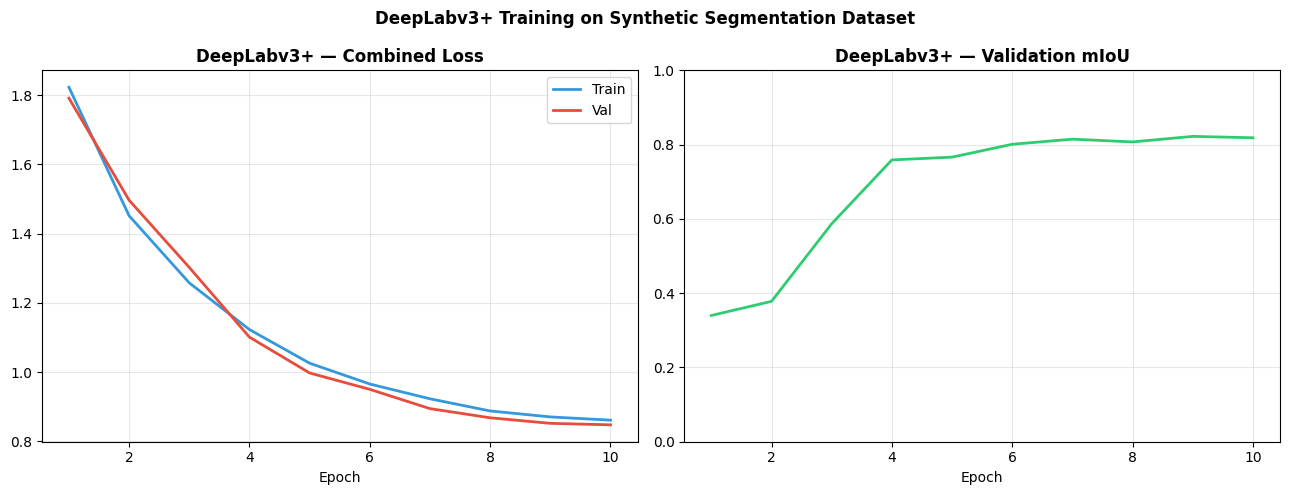

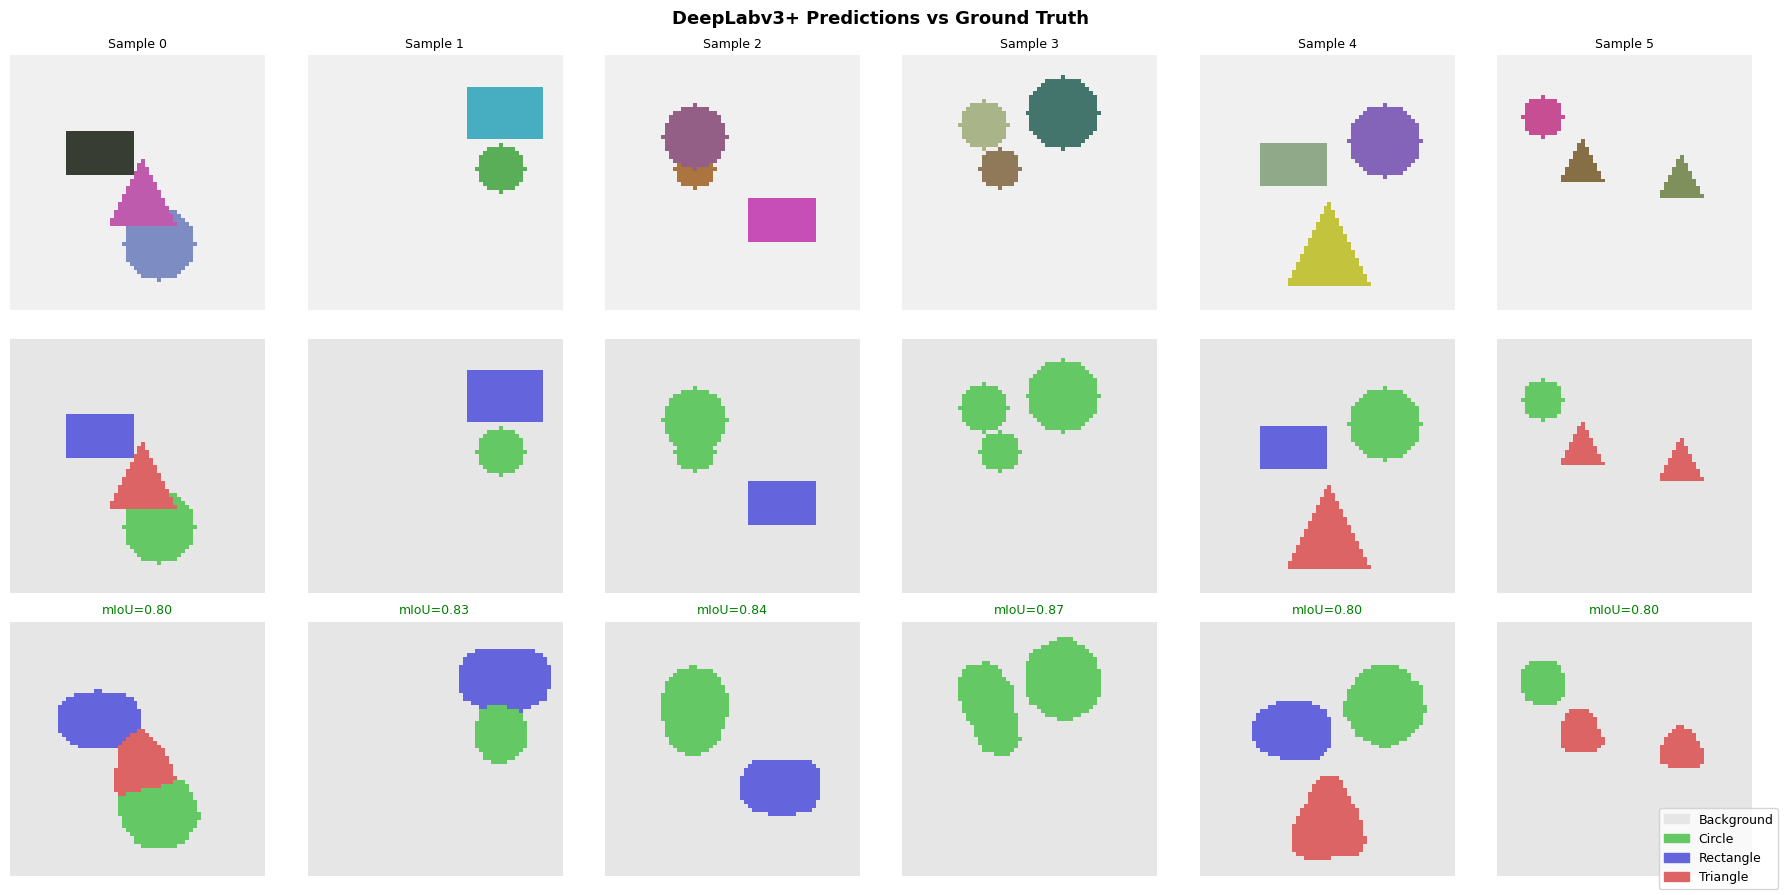

Saved deeplab_training.png  deeplab_predictions.png


In [6]:
# ── Plot training curves ───────────────────────────────────────────────────────
ep = range(1, 11)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(ep, hist_dl['train'], label='Train', color='#3498db', lw=2)
axes[0].plot(ep, hist_dl['val'],   label='Val',   color='#e74c3c', lw=2)
axes[0].set_title('DeepLabv3+ — Combined Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, hist_dl['miou'], color='#2ecc71', lw=2)
axes[1].set_title('DeepLabv3+ — Validation mIoU', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylim(0, 1); axes[1].grid(True, alpha=0.3)

plt.suptitle('DeepLabv3+ Training on Synthetic Segmentation Dataset', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('deeplab_training.png', dpi=100, bbox_inches='tight')
plt.show()

# ── Visualise predictions ─────────────────────────────────────────────────────
cmap_rgb = np.array([[230,230,230],[100,200,100],[100,100,220],[220,100,100]], dtype=np.uint8)
model_dl.eval()
imgs_v, masks_v = next(iter(val_dl))
with torch.no_grad():
    preds_v = model_dl(imgs_v.to(DEVICE)).argmax(1).cpu()

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
for i in range(6):
    axes[0,i].imshow(imgs_v[i].permute(1,2,0).numpy())
    axes[1,i].imshow(cmap_rgb[masks_v[i].numpy()])
    axes[2,i].imshow(cmap_rgb[preds_v[i].numpy()])
    gt_m, pred_m = masks_v[i], preds_v[i]
    ious = []
    for c in range(4):
        inter = ((pred_m==c)&(gt_m==c)).sum().item()
        union = ((pred_m==c)|(gt_m==c)).sum().item()
        ious.append(inter/union if union else float('nan'))
    mi = np.nanmean(ious)
    axes[2,i].set_title(f'mIoU={mi:.2f}', fontsize=9, color='green' if mi > 0.5 else 'red')
    axes[0,i].set_title(f'Sample {i}', fontsize=9)
    for r in range(3): axes[r,i].axis('off')
axes[0,0].set_ylabel('Input',        fontsize=10, fontweight='bold')
axes[1,0].set_ylabel('Ground Truth', fontsize=10, fontweight='bold')
axes[2,0].set_ylabel('DeepLab Pred', fontsize=10, fontweight='bold')
patches = [mpatches.Patch(color=np.array(c)/255, label=n)
           for c, n in zip(cmap_rgb, ['Background','Circle','Rectangle','Triangle'])]
fig.legend(handles=patches, loc='lower right', fontsize=9)
plt.suptitle('DeepLabv3+ Predictions vs Ground Truth', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('deeplab_predictions.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved deeplab_training.png  deeplab_predictions.png')

## Section 5: DeepLab vs U-Net — Design Comparison

| Property | U-Net | DeepLabv3+ |
|----------|-------|------------|
| Upsampling | Symmetric decoder (learnable) | Bilinear × ASPP decoder |
| Multi-scale | Only through skip connections | ASPP captures 4 scales in parallel |
| Skip connection | Concat at every level | Single low-level feature |
| Output stride | 16 (typical) | 16 or 8 (adjustable with atrous) |
| Best for | Medical, small datasets | Natural images, large datasets |
| Backbone | Custom encoder | ResNet / Xception (pretrained) |
| CRF post-proc | Not used | DeepLabv1/v2 used CRF (removed in v3+) |

### When to Use Which
- **U-Net** → medical imaging, satellite, any task with limited data and fine boundary detail
- **DeepLab** → natural scene segmentation (Cityscapes, ADE20K) where large receptive field and multi-scale context matter
- **In practice** → DeepLabv3+ with a pretrained ResNet-50/101 backbone is a very strong baseline for most tasks

### Key Takeaways

| Concept | Summary |
|---------|--------|
| **Atrous conv** | Same params as 3×3, larger RF; `dilation=r` in PyTorch |
| **ASPP** | Parallel atrous branches + GAP → multi-scale context in one layer |
| **Output stride** | DeepLab keeps OS=16 instead of OS=32, preserving 4× more spatial detail |
| **DeepLabv3+** | ASPP encoder + lightweight decoder fusing low-level features |
| **GAP branch** | Global average pool captures global image-level context |

### Exercises
1. Add a second low-level skip connection (from stride-2 features) to the decoder — does mIoU improve?
2. Try dilation rates `(12, 24, 36)` (wider pyramid) — how does it affect performance on this dataset?
3. Replace the `SimpleBackbone` with `torchvision.models.resnet18` as the encoder.
4. Implement the CRF post-processing from DeepLabv1 using `pydensecrf`.
5. Benchmark: freeze the backbone and only train ASPP+decoder — how many fewer epochs to converge?